In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
import argparse
from pprint import pprint
import pickle as pkl
import glob
import shutil
import copy
import json

import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as scipy_R
from tqdm.auto import tqdm
from ultralytics import RTDETR
import networkx as nx

import cv2
import open3d as o3d
import matplotlib.pyplot as plt
import matplotlib.patches as patches
np.set_printoptions(suppress=True)

from preprocess import MapGraph, QueryGraph
from preprocess.scannet_utils import ScanNetLoader, get_fov, create_color_map, create_camera_frame, create_cuboid

from preprocess.utils import (
    # GloveFeatureExtractor,
    # LAVISFeatureExtractor,
    comp_bbox3d_edge_with_min_knn,
    comp_bbox2d_edge_with_min_knn,
)

from utils import (
    comp_graph_overlap,
    transform_bbox3d,
    invert_Rt,
    compute_IoU_x0y0wh,
    compute_IoU_xyxy
)

from eva import (
    compute_pose_error,
)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
SCANNET_PATH = 'data/ScanNet/scannet_by_tr3d_with_DepthImage'
GRAPH_PATH = 'data/scannet_graph'

# if os.path.exists(GRAPH_PATH):
#     shutil.rmtree(GRAPH_PATH)
# os.makedirs(GRAPH_PATH)

scannet_loader = ScanNetLoader(SCANNET_PATH)

In [3]:
SCENE_ID = 'scene0000_00'
FRAME_ID = 0

In [4]:
rtdetr_model = RTDETR('object-detection/rtdetr-l.pt')
coco_id2name = json.load(open('object-detection/coco_id2name.json'))

In [5]:
# lavis_feature_extractor = LAVISFeatureExtractor()
# glove_feature_extractor = GloveFeatureExtractor('glove/glove.6B.100d.txt')

def encode_text_features(label_names, label_ids, type, n_labels=None):
    # if type == 'blipv2':
    #     feats = []
    #     for label_name in label_names:
    #         text_features = lavis_feature_extractor.extract_text_features(label_name)
    #         text_feature = text_features['text']
    #         norm_text_feature = text_features['norm_text']
    #         feats.append(text_feature)
    #     feats = np.vstack(feats)
    # if type == 'glove':
    #     feats = []
    #     for label_name in label_names:
    #         text_feature = glove_feature_extractor.extract_feature(label_name)
    #         feats.append(text_feature)
    #     feats = np.vstack(feats)
    if type == 'onehot':
        assert n_labels is not None
        feats = np.zeros((len(label_ids), n_labels))
        feats[np.arange(len(label_ids)), label_ids - 1] = 1
    return feats

In [47]:
def detection_to_bbox2d_df(rgb_path, orig_img_size, img_size):
    sx = img_size[0] / orig_img_size[0]
    sy = img_size[1] / orig_img_size[1]
    result = rtdetr_model(rgb_path)[0]
    bbox2d_from_detect_df = pd.DataFrame(result.boxes.xyxy.cpu().numpy(), columns=['x0', 'y0', 'x1', 'y1'])
    bbox2d_from_detect_df['x0'] = bbox2d_from_detect_df['x0'].values * sx
    bbox2d_from_detect_df['y0'] = bbox2d_from_detect_df['y0'].values * sy
    bbox2d_from_detect_df['x1'] = bbox2d_from_detect_df['x1'].values * sx
    bbox2d_from_detect_df['y1'] = bbox2d_from_detect_df['y1'].values * sy
    bbox2d_from_detect_df['w'] = bbox2d_from_detect_df['x1'] - bbox2d_from_detect_df['x0']
    bbox2d_from_detect_df['h'] = bbox2d_from_detect_df['y1'] - bbox2d_from_detect_df['y0']
    bbox2d_from_detect_df['cx'] = bbox2d_from_detect_df['x0'] + bbox2d_from_detect_df['w'] / 2
    bbox2d_from_detect_df['cy'] = bbox2d_from_detect_df['y0'] + bbox2d_from_detect_df['h'] / 2 
    bbox2d_from_detect_df['label_id'] = result.boxes.cls.cpu().numpy().astype(int)
    bbox2d_from_detect_df['label_name'] = bbox2d_from_detect_df['label_id'].map(str).map(coco_id2name)
    return bbox2d_from_detect_df

In [48]:
def scannet_to_node_qry_graph_from_real(scene_id, frame_id):
    # camera params
    _, align_matrix = scannet_loader.get_bbox3d_and_align_matrix(scene_id)
    t_wc, R_wc = scannet_loader.get_cam_pose(scene_id, frame_id, align_matrix)
    if np.any(np.isnan(t_wc)) or np.any(np.isnan(R_wc.as_quat())) or np.any(np.isinf(t_wc)) or np.any(np.isinf(R_wc.as_quat())):
        return None
    cam_pose = np.concatenate([t_wc, R_wc.as_quat()], axis=0)
    intrinsics = scannet_loader.get_intrinsics(scene_id)
    orig_img_size = scannet_loader.orig_img_size
    img_size = scannet_loader.img_size

    # bbox from detection
    rgb_path = scannet_loader.get_rgb_path(scene_id, frame_id)
    bbox2d_from_detect_df = detection_to_bbox2d_df(rgb_path, orig_img_size, img_size)

    qry_df = bbox2d_from_detect_df.add_prefix('bbox_from_detect_') \
        .rename(columns={'bbox_from_detect_label_name': 'label_name',
                        'bbox_from_detect_label_id': 'label_id'}).copy()
    label_names = qry_df['label_name']
    label_ids = qry_df['label_id']

    node_ids = np.arange(len(qry_df))
    inst_ids = np.arange(len(qry_df))
    inst2node = {inst_id: node_id for node_id, inst_id in enumerate(inst_ids)}

    # text features
    onehot_label_embs = encode_text_features(
        label_names, label_ids, 'onehot', n_labels=80)
    # glove_label_embs = encode_text_features(label_names, label_ids, 'glove')
    # blip_label_embs = encode_text_features(label_names, label_ids, 'blipv2')

    features = {
        **{k: np.asarray(v).reshape(-1, 1) for k, v in qry_df.items()},
        # 'blip_label_embs': blip_label_embs,
        # 'glove_label_embs': glove_label_embs,
        'onehot_label_embs': onehot_label_embs,
    }

    data = {
        'step': frame_id,
        'features': features,
        'total_obj_cnt': len(qry_df),
        'inst_ids': inst_ids,
        'node_ids': node_ids,
        'inst2node': inst2node,
        'camera_pose': cam_pose,
        'camera_intrinsics': intrinsics,
        'img_size': scannet_loader.img_size,
    }

    return data

In [49]:
def gen_query_graph_from_real(scene_id, frame_id, edge2d_k, edge3d_k):
    data = scannet_to_node_qry_graph_from_real(scene_id, frame_id)
    if data is None:
        return None
    node_ids = data['node_ids']    

    cxcy_cols = ['bbox_from_detect_cx', 'bbox_from_detect_cy']
    bbox2d_cxcy_df = pd.DataFrame({k: data['features'][k][:, 0] for k in cxcy_cols})
    edge_index_2d, edge_attr_2d = comp_bbox2d_edge_with_min_knn(bbox2d_cxcy_df, cxcy_cols, node_ids, k=edge2d_k)
    # edge 3d from depth
    # xyz_cols = ['bbox3d_from_depth_tx', 'bbox3d_from_depth_ty', 'bbox3d_from_depth_tz']
    # bbox3d_from_depth_t_df = pd.DataFrame({k: data['features'][k][:, 0] for k in xyz_cols})
    # edge_index_3d_from_depth, edge_attr_3d_from_depth = comp_bbox3d_edge_with_min_knn(
    #     bbox3d_from_depth_t_df, xyz_cols, node_ids, k=edge3d_k)

    data.update({
        'edge': {
            '2d': {
                'index': edge_index_2d,
                'attr': edge_attr_2d,
            },
            # '3d_from_depth': {
            #     'index': edge_index_3d_from_depth,
            #     'attr': edge_attr_3d_from_depth,
            # },
        }
    })
    return data

In [50]:
g = gen_query_graph_from_real(SCENE_ID, FRAME_ID, edge2d_k=-1, edge3d_k=-1)


image 1/1 /home/alan/obj_graph_matching/data/ScanNet/scannet_by_tr3d_with_DepthImage/posed_images/scene0000_00/00000.jpg: 640x640 1 56, 1 59, 1 60, 2 65s, 5 73s, 175.6ms
Speed: 17.4ms preprocess, 175.6ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


In [77]:
bbox2d_df = scannet_loader.get_bbox2d(SCENE_ID, FRAME_ID)
bbox2d_df['x1'] = bbox2d_df['x0'] + bbox2d_df['w']
bbox2d_df['y1'] = bbox2d_df['y0'] + bbox2d_df['h']
label_ids = bbox2d_df['c'].values
label_names = scannet_loader.get_label_names(label_ids, 'nyu40class')
bbox2d_df['label_name'] = label_names
bbox2d_df['label_id'] = label_ids
bbox2d_df

,x0,y0,w,h,cx,cy,c,x1,y1,label_name,label_id
0,0.000000,0.00000,610.431790,346.516356,305.215895,173.258178,16.0,610.431790,346.516356,curtain,16.0
1,0.000000,0.00000,155.303155,116.068263,77.651577,58.034132,16.0,155.303155,116.068263,curtain,16.0
2,0.000000,0.00000,237.384092,451.033226,118.692046,225.516613,14.0,237.384092,451.033226,desk,14.0
3,253.399620,134.41354,360.951228,311.949575,433.875234,290.388328,7.0,614.350848,446.363115,table,7.0
4,44.367605,0.00000,391.735374,331.546577,240.235292,165.773289,3.0,436.102979,331.546577,cabinet,3.0


In [78]:
rgb_path = scannet_loader.get_rgb_path(SCENE_ID, FRAME_ID)
orig_img_size = scannet_loader.orig_img_size
img_size = scannet_loader.img_size
print(orig_img_size, img_size)
# bbox from RT-DETR
bbox2d_from_detect_df = detection_to_bbox2d_df(rgb_path, orig_img_size, img_size)
bbox2d_from_detect_df['x1'] = bbox2d_from_detect_df['x0'] + bbox2d_from_detect_df['w']
bbox2d_from_detect_df['y1'] = bbox2d_from_detect_df['y0'] + bbox2d_from_detect_df['h']
bbox2d_from_detect_df

(1296, 968) (640, 480)


image 1/1 /home/alan/obj_graph_matching/data/ScanNet/scannet_by_tr3d_with_DepthImage/posed_images/scene0000_00/00000.jpg: 640x640 1 56, 1 59, 1 60, 2 65s, 5 73s, 271.1ms
Speed: 13.7ms preprocess, 271.1ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


,x0,y0,x1,y1,w,h,cx,cy,label_id,label_name
0,2.734509,113.966080,179.188370,433.341553,176.453857,319.375488,90.961441,273.653809,56,chair
1,442.740784,251.507629,484.007202,278.509430,41.266418,27.001801,463.373993,265.008545,65,remote
2,267.173553,168.462387,608.545715,444.084412,341.372162,275.622009,437.859619,306.273376,60,dining table
3,388.880707,124.751556,421.868134,208.234695,32.987427,83.483139,405.374420,166.493134,73,book
4,419.605072,144.537933,457.484467,217.065781,37.879395,72.527847,438.544769,180.801849,73,book
5,124.847267,207.423065,167.900238,244.351349,43.052971,36.928284,146.373749,225.887207,73,book
6,337.771729,194.935028,456.221130,264.964355,118.449402,70.029327,396.996429,229.949692,73,book
7,135.474167,227.188721,186.934174,272.737976,51.460007,45.549255,161.204163,249.963348,73,book
8,333.773987,195.281967,353.718231,225.252869,19.944244,29.970901,343.746094,210.267426,65,remote
9,187.978760,3.112006,612.027588,443.205048,424.048828,440.093048,400.003174,223.158524,59,bed


In [99]:
def viz_bbox(img, bbox_xyxy, labels):
    for i, box in enumerate(bbox_xyxy):
        x0, y0, x1, y1 = box
        cv2.rectangle(img, (int(x0), int(y0)), (int(x1), int(y1)), (0, 255, 0), 1)
        if labels is not None:
            label = labels[i]
            cv2.putText(img, label, (int(x0), int(y1)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1, cv2.LINE_AA)
    return img

In [103]:
def fig_ax_to_img(fig, ax, keep_alpha=False):
    ax.axis('off')
    fig.tight_layout(pad=0)

    # To remove the huge white borders
    ax.margins(0)

    fig.canvas.draw()
    img = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    img = img.reshape(fig.canvas.get_width_height()[::-1] + (4,))
    if not keep_alpha:
        img = img[:, :, :3]
    return img

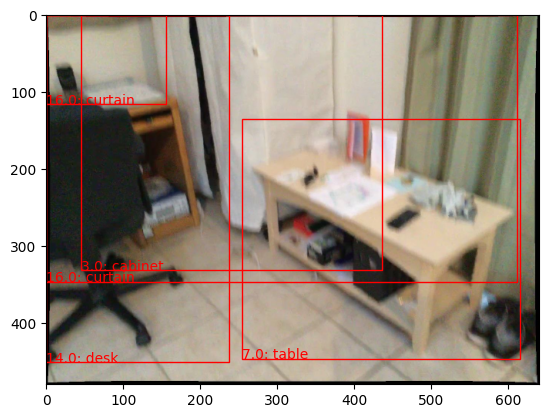

In [113]:
fig0, ax0 = scannet_loader.viz_2d_scene(SCENE_ID, FRAME_ID, 'nyu40class')
img0 = fig_ax_to_img(fig0, ax0)

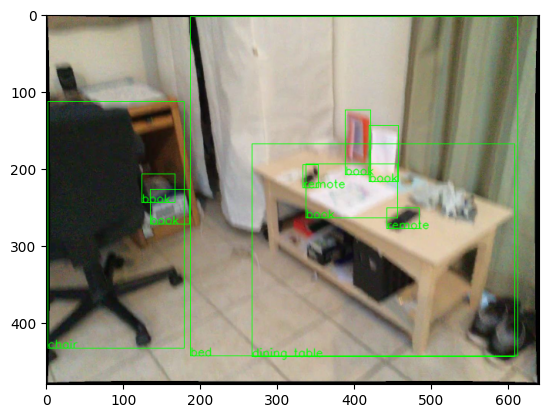

In [114]:
img1 = scannet_loader.get_rgb_img(SCENE_ID, FRAME_ID)
viz_bbox(img1, bbox2d_from_detect_df[['x0', 'y0', 'x1', 'y1']].values, bbox2d_from_detect_df['label_name'].values)
plt.imshow(img1)

In [115]:
def concat_imgs(imgs: list, axis=1, pad_px: int = 0, pad_color: list = (255, 255, 255)):
    if pad_px > 0:
        pad_shape = (pad_px, imgs[0].shape[1], imgs[0].shape[2]) if axis == 0 else (
            imgs[0].shape[0], pad_px, imgs[0].shape[2])
        padding = np.full(pad_shape, pad_color, dtype=np.uint8)
        return np.concatenate([np.concatenate([x, padding], axis=axis) for x in imgs[:-1]] + [imgs[-1]], axis=axis)
    else:
        return np.concatenate(imgs, axis=axis)

In [116]:
def comp_corr_by_iou(bbox_src_df, bbox_ref_df):
    iou_g = nx.Graph()
    iou_table = pd.DataFrame(np.zeros((len(bbox_src_df), len(bbox_ref_df))),
                            index=bbox_src_df['label_name'].values, 
                            columns=bbox_ref_df['label_name'].values)
    for i, bbox_src in enumerate(bbox_src_df[['x0', 'y0', 'x1', 'y1']].values):
        for j, bbox_ref in enumerate(bbox_ref_df[['x0', 'y0', 'x1', 'y1']].values):
            iou = compute_IoU_xyxy(bbox_src, bbox_ref)
            iou_table.iloc[i, j] = iou*100
            if iou > 0:
                iou_g.add_edge(i, len(bbox_src_df)+j, weight=-iou)
    matching = nx.algorithms.bipartite.minimum_weight_full_matching(iou_g, np.arange(len(bbox_src_df)))
    src2ref = {k: v-len(bbox_src_df) for k, v in matching.items() if k < len(bbox_src_df)}
    corr = np.array([[k, v] for k, v in src2ref.items()]).T
    return corr, iou_table

In [117]:
corr, iou_tbl = comp_corr_by_iou(bbox2d_from_detect_df, bbox2d_df)
print(corr)
iou_tbl

[[0 2 6 7 9]
 [1 3 4 2 0]]


,curtain,curtain,desk,table,cabinet
chair,18.089158,0.433064,52.634752,0.000000,18.696317
remote,0.526779,0.000000,0.000000,0.989593,0.000000
dining table,24.826316,0.000000,0.000000,83.562046,14.026032
book,1.301926,0.000000,0.000000,2.156596,2.120361
book,1.298814,0.000000,0.000000,2.439916,0.910419
book,0.751625,0.000000,1.484917,0.000000,1.224123
book,3.921497,0.000000,0.000000,7.366817,5.245037
book,1.108129,0.000000,2.189228,0.000000,1.804736
remote,0.282590,0.000000,0.000000,0.530865,0.460235
bed,57.324179,0.000000,7.995313,58.755465,34.676674


In [118]:
def viz_corr_on_bbox(src_img, ref_img, bbox_src_cxcy, bbox_ref_cxcy, corr):
    assert corr.shape[0] == 2, f'corr shape (2, n), but got {corr.shape}'
    assert max(corr[0]) < len(bbox_src_cxcy), f'corr[0] should be less than len(bbox_src) {len(bbox_src_cxcy)}, but got {max(corr[0])}'
    assert max(corr[1]) < len(bbox_ref_cxcy), f'corr[1] should be less than len(bbox_ref) {len(bbox_ref_cxcy)}, but got {max(corr[1])}'

    imgs = concat_imgs([src_img, ref_img])

    for src_idx, ref_idx in corr.T:
        src_pt = bbox_src_cxcy[src_idx]
        ref_pt = bbox_ref_cxcy[ref_idx]
        # shift
        src_pt[0] += src_img.shape[1]
        cv2.line(imgs, tuple(src_pt.astype(int)), tuple(ref_pt.astype(int)), (255, 255, 0), 1)
        cv2.circle(imgs, tuple(src_pt.astype(int)), 2, (0, 255, 0), 2)
        cv2.circle(imgs, tuple(ref_pt.astype(int)), 2, (255, 0, 0), 2)
    return imgs

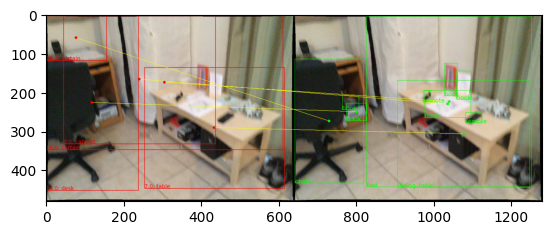

In [119]:
corr_img = viz_corr_on_bbox(img0, img1, bbox2d_from_detect_df[['cx', 'cy']].values, bbox2d_df[['cx', 'cy']].values, corr)
plt.imshow(corr_img)